<a href="https://colab.research.google.com/github/anafrodrigues95-rgc/geomodelagem_uenf/blob/main/Geomodelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install cdsapi
%pip install netcdf4

import cdsapi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.3 MB/s eta 0:00:00


In [ ]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["2m_temperature"],
    "year": ["2025"],
    "month": ["09"],
    "day": ["12"],
    "time": ["08:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [90, -180, -90, 180]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='1e59e4ff-9b93-4cff-8896-edd8ab12b379')
client.retrieve(dataset, request).download()

2026-07-01 13:25:33,660 INFO Request ID is d370ec0b-5602-4ac3-86bf-0e4ed66d8b0c
INFO:ecmwf.datastores.legacy_client:Request ID is d370ec0b-5602-4ac3-86bf-0e4ed66d8b0c
2026-07-01 13:25:33,740 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-01 13:26:28,330 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


2f4f7f3b1dcd2c17468e8b40e660bd2e.nc:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

'2f4f7f3b1dcd2c17468e8b40e660bd2e.nc'

In [ ]:
#Colab only
from google.colab import drive
drive.mount ('/content/drive')



Mounted at /content/drive


In [ ]:
import xarray as xr
import pandas as pd


In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/2f4f7f3b1dcd2c17468e8b40e660bd2e.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('Dataset converted to DataFrame and saved to output_data_irradiance.csv')

Dataset converted to DataFrame and saved to output_data_irradiance.csv


In [ ]:
df_converted

t2m  number expver
valid_time          latitude longitude                           
2025-09-12 08:00:00  90.0    -180.00    271.411743       0   0001
                             -179.75    271.411743       0   0001
                             -179.50    271.411743       0   0001
                             -179.25    271.411743       0   0001
                             -179.00    271.411743       0   0001
...                                            ...     ...    ...
                    -90.0     178.75    214.722275       0   0001
                              179.00    214.722275       0   0001
                              179.25    214.722275       0   0001
                              179.50    214.722275       0   0001
                              179.75    214.722275       0   0001

[1038240 rows x 3 columns]

In [ ]:
!pip install cartopy
import cartopy

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

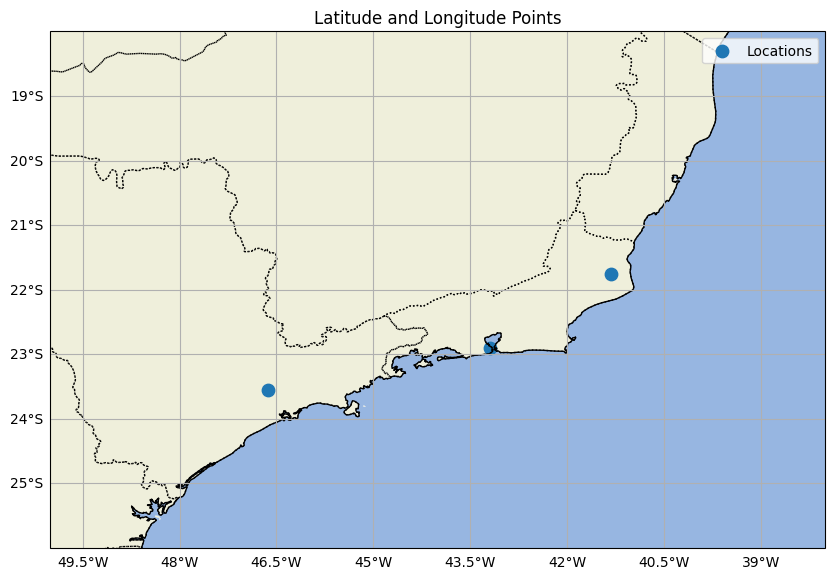

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example latitude and longitude data
latitudes = [-23.55, -22.90, -21.76]
longitudes = [-46.63, -43.20, -41.32]

# Create figure
plt.figure(figsize=(10, 8))

# Map projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')

# Plot points
ax.scatter(
    longitudes,
    latitudes,
    s=80,
    marker='o',
    transform=ccrs.PlateCarree(),
    label='Locations'
)

# Define map extent: [min_lon, max_lon, min_lat, max_lat]
ax.set_extent([-50, -38, -26, -18], crs=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# Title and legend
plt.title("Latitude and Longitude Points")
plt.legend()

plt.show()

In [ ]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["potential_evaporation"],
    "year": ["2025"],
    "month": ["06"],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

client = cdsapi.Client(url= 'https://cds.climate.copernicus.eu/api',
key= '1e59e4ff-9b93-4cff-8896-edd8ab12b379')
client.retrieve(dataset, request).download()

2026-07-01 13:27:35,706 INFO Request ID is b342b3e8-d5ea-445a-9af1-182aac4384b5
INFO:ecmwf.datastores.legacy_client:Request ID is b342b3e8-d5ea-445a-9af1-182aac4384b5
2026-07-01 13:27:35,791 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-01 13:27:57,324 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-01 13:28:08,773 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e8db560da8af3307efcdb3eb01501eac.nc:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

'e8db560da8af3307efcdb3eb01501eac.nc'

In [ ]:
ds = xr.open_dataset('/content/e8db560da8af3307efcdb3eb01501eac.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('Evapotranpiracao.csv')

Evapotranpiracao.csv


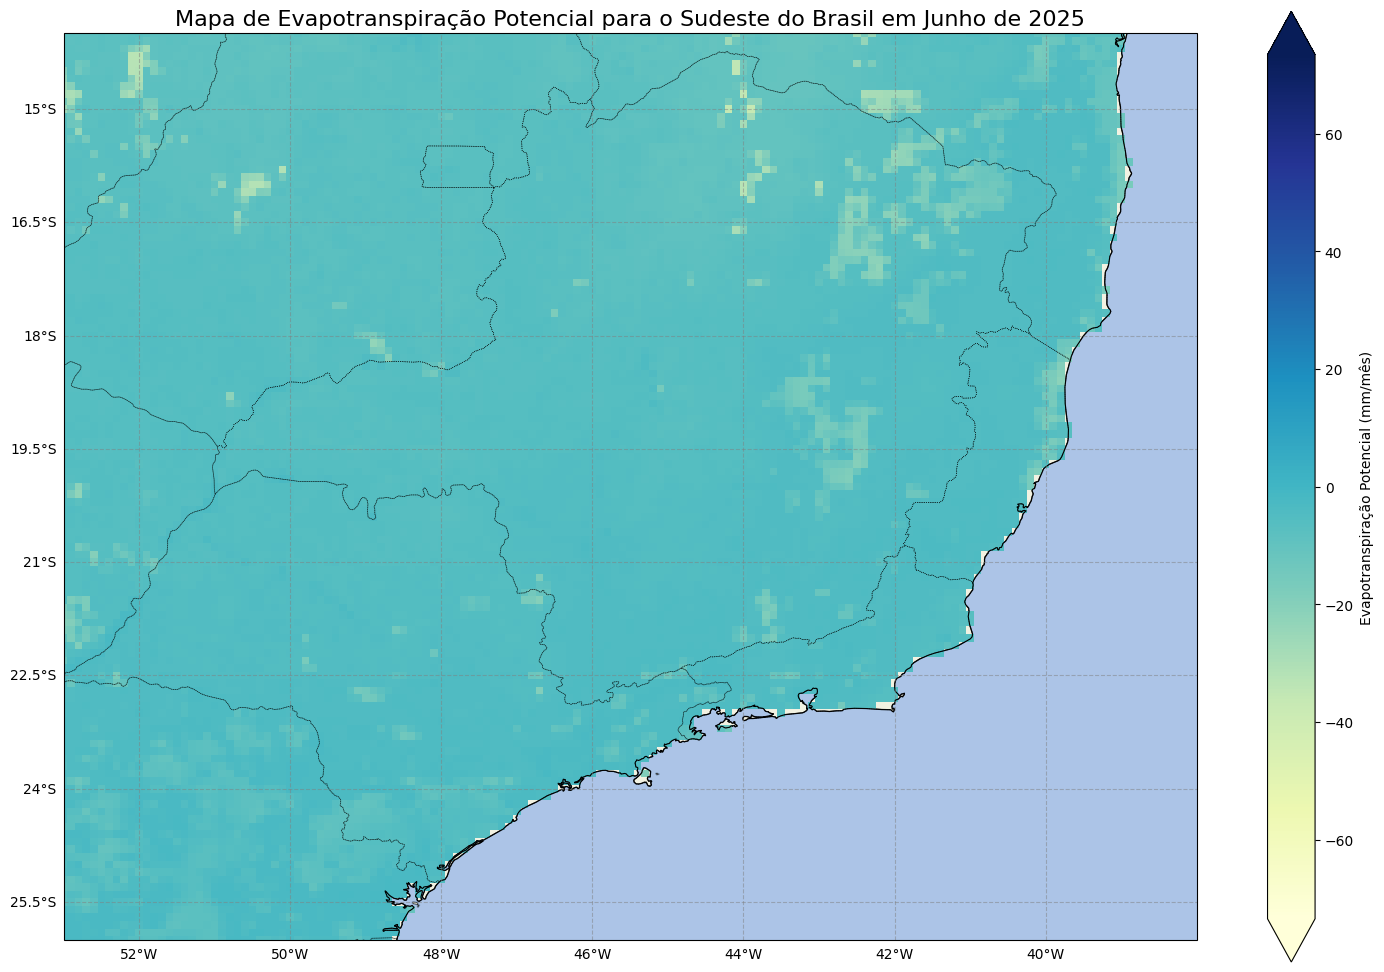

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd

# Function to adjust longitude from 0-360 to -180-180 for plotting
def adjust_longitude(ds_input):
    ds_output = ds_input.copy()
    ds_output['longitude'] = (ds_output['longitude'] + 180) % 360 - 180
    # Ensure sorting after adjustment to prevent plotting issues
    ds_output = ds_output.sortby('longitude')
    return ds_output

# Adjust longitude for plotting
ds_adjusted = adjust_longitude(ds)

# Extract the 'pev' (potential evaporation) variable and remove the time dimension
pev_data = ds_adjusted['pev'].squeeze()

# Create figure and axes with a PlateCarree projection
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.8)
ax.add_feature(cfeature.OCEAN, alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5) # Add states boundaries

# Plot the potential evaporation data using pcolormesh
# Convert from m/month to mm/month (1 meter = 1000 millimeters)
pev_mm = pev_data * 1000
img = pev_mm.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x='longitude',
    y='latitude',
    cmap='YlGnBu', # Yellow-Green-Blue colormap is suitable for evaporation
    cbar_kwargs={'label': 'Evapotranspiração Potencial (mm/mês)'}, # Colorbar label in Portuguese
    add_colorbar=True,
    extend='both' # Extend colormap for values outside range if any
)

# Set title for the map
time_val = pd.to_datetime(pev_data['valid_time'].item())
ax.set_title(f'Mapa de Evapotranspiração Potencial para o Sudeste do Brasil em {time_val.strftime("%B de %Y").replace("June", "Junho")}', fontsize=16)

# Set extent for Southeast Brazil: [min_lon, max_lon, min_lat, max_lat]
# Approximate coordinates for Southeast Brazil
ax.set_extent([-53, -38, -26, -14], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Mapa de Evapotranspiração Potencial para o Norte do Brasil

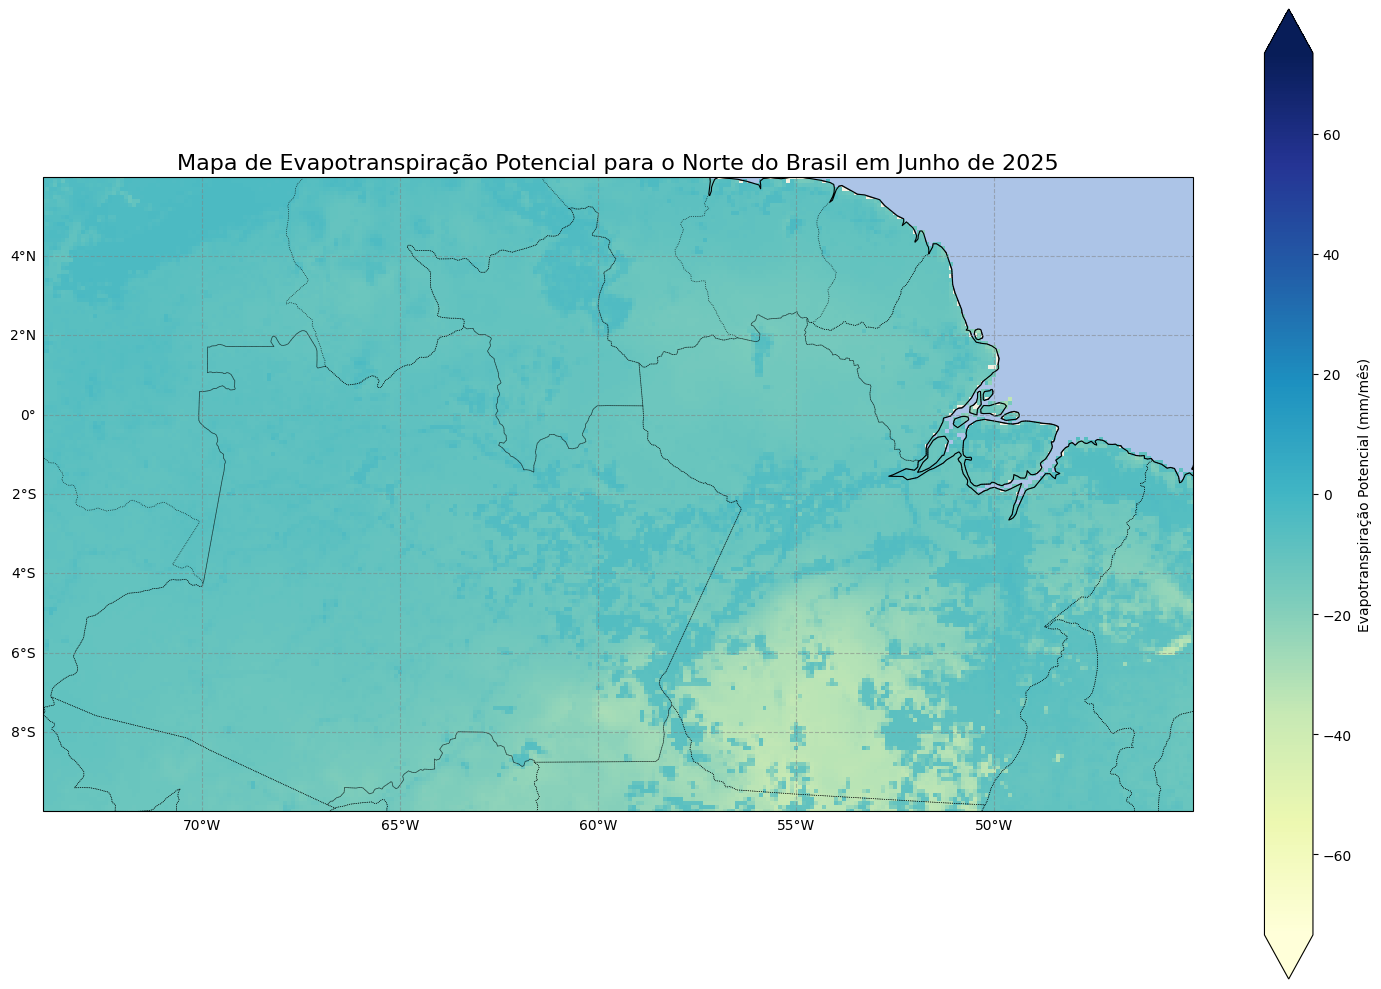

In [ ]:
!pip install cartopy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import xarray as xr

# Re-open the dataset here to ensure 'ds' is defined
ds = xr.open_dataset('/content/e8db560da8af3307efcdb3eb01501eac.nc', engine='h5netcdf')

# Adjust longitude for plotting (already defined in previous cell, but keeping for self-containment if this cell is run independently)
def adjust_longitude(ds_input):
    ds_output = ds_input.copy()
    ds_output['longitude'] = (ds_output['longitude'] + 180) % 360 - 180
    ds_output = ds_output.sortby('longitude')
    return ds_output

# Adjust longitude for plotting
ds_adjusted = adjust_longitude(ds)

# Extract the 'pev' (potential evaporation) variable and remove the time dimension
pev_data = ds_adjusted['pev'].squeeze()

# Create figure and axes with a PlateCarree projection
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.8)
ax.add_feature(cfeature.OCEAN, alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5) # Add states boundaries

# Plot the potential evaporation data using pcolormesh
# Convert from m/month to mm/month (1 meter = 1000 millimeters)
pev_mm = pev_data * 1000
img = pev_mm.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x='longitude',
    y='latitude',
    cmap='YlGnBu', # Yellow-Green-Blue colormap is suitable for evaporation
    cbar_kwargs={'label': 'Evapotranspiração Potencial (mm/mês)'}, # Colorbar label in Portuguese
    add_colorbar=True,
    extend='both'
)

# Set title for the map
time_val = pd.to_datetime(pev_data['valid_time'].item())
ax.set_title(f'Mapa de Evapotranspiração Potencial para o Norte do Brasil em {time_val.strftime("%B de %Y").replace("June", "Junho")}', fontsize=16)

# Set extent for Northern Brazil: [min_lon, max_lon, min_lat, max_lat]
# Approximate coordinates for Northern Brazil
ax.set_extent([-74, -45, -10, 6], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

plt.tight_layout()
plt.show()

### Mapa de Evapotranspiração Potencial para Igarapé-Miri (PA)

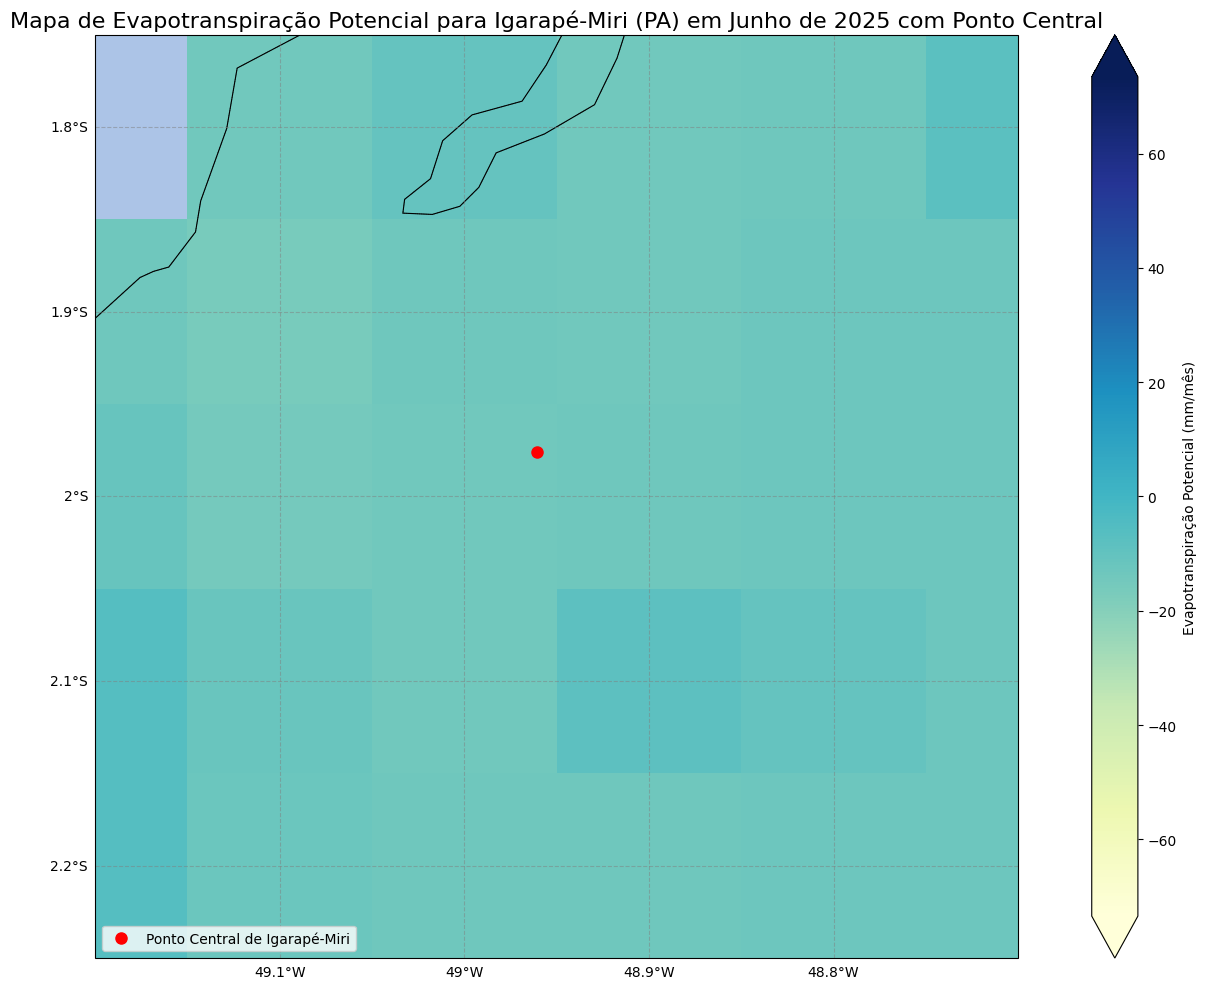

In [ ]:
!pip install cartopy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import xarray as xr

# Re-open the dataset here to ensure 'ds' is defined if this cell is run independently
ds = xr.open_dataset('/content/e8db560da8af3307efcdb3eb01501eac.nc', engine='h5netcdf')

# Function to adjust longitude from 0-360 to -180-180 for plotting
def adjust_longitude(ds_input):
    ds_output = ds_input.copy()
    ds_output['longitude'] = (ds_output['longitude'] + 180) % 360 - 180
    ds_output = ds_output.sortby('longitude')
    return ds_output

# Adjust longitude for plotting
ds_adjusted = adjust_longitude(ds)

# Extract the 'pev' (potential evaporation) variable and remove the time dimension
pev_data = ds_adjusted['pev'].squeeze()

# Convert DMS to Decimal Degrees (copied from the location map cell for self-containment)
def dms_to_dd(degrees, minutes, seconds, direction):
    dd = float(degrees) + float(minutes)/60 + float(seconds)/3600
    if direction == 'S' or direction == 'W':
        dd *= -1
    return dd

# Given coordinates for Igarapé-Miri (copied from the location map cell)
lat_deg, lat_min, lat_sec, lat_dir = 1, 58, 33, 'S'
lon_deg, lon_min, lon_sec, lon_dir = 48, 57, 39, 'W'

latitude_igarapemiri = dms_to_dd(lat_deg, lat_min, lat_sec, lat_dir)
longitude_igarapemiri = dms_to_dd(lon_deg, lon_min, lon_sec, lon_dir)

# Create figure and axes with a PlateCarree projection
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.8)
ax.add_feature(cfeature.OCEAN, alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5) # Add states boundaries

# Plot the potential evaporation data using pcolormesh
# Convert from m/month to mm/month (1 meter = 1000 millimeters)
pev_mm = pev_data * 1000
img = pev_mm.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x='longitude',
    y='latitude',
    cmap='YlGnBu', # Yellow-Green-Blue colormap is suitable for evaporation
    cbar_kwargs={'label': 'Evapotranspiração Potencial (mm/mês)'}, # Colorbar label in Portuguese
    add_colorbar=True,
    extend='both'
)

# Plot the specific central location of Igarapé-Miri
ax.plot(
    longitude_igarapemiri,
    latitude_igarapemiri,
    'ro', # Red circle marker
    markersize=8,
    transform=ccrs.PlateCarree(),
    label='Ponto Central de Igarapé-Miri'
)

# Set title for the map
time_val = pd.to_datetime(pev_data['valid_time'].item())
ax.set_title(f'Mapa de Evapotranspiração Potencial para Igarapé-Miri (PA) em {time_val.strftime("%B de %Y").replace("June", "Junho")} com Ponto Central', fontsize=16)

# Set extent for Igarapé-Miri, PA: [min_lon, max_lon, min_lat, max_lat]
# Coordenadas fornecidas: ValorLatitude Norte (máx)-1,75 Latitude Sul (mín)-2,25 Longitude Oeste (mín)-49,20 Longitude Leste (máx)-48,70
ax.set_extent([-49.20, -48.70, -2.25, -1.75], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

plt.legend(loc='lower left') # Add legend to show the marker label
plt.tight_layout()
plt.show()

### Mapa de Localização para Igarapé-Miri (PA) com Ponto Central

Latitude Decimal: -1.9758333333333336
Longitude Decimal: -48.96083333333333


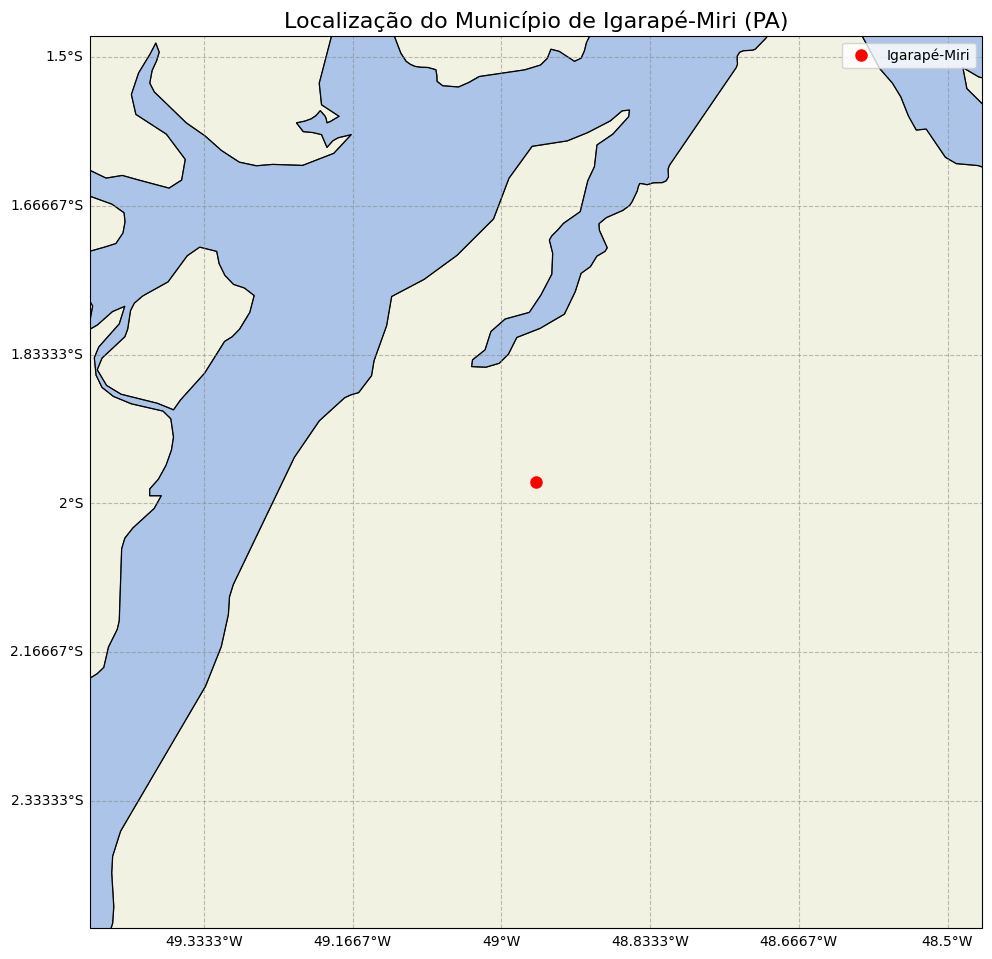

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Convert DMS to Decimal Degrees
def dms_to_dd(degrees, minutes, seconds, direction):
    dd = float(degrees) + float(minutes)/60 + float(seconds)/3600
    if direction == 'S' or direction == 'W':
        dd *= -1
    return dd

# Given coordinates for Igarapé-Miri
lat_deg, lat_min, lat_sec, lat_dir = 1, 58, 33, 'S'
lon_deg, lon_min, lon_sec, lon_dir = 48, 57, 39, 'W'

latitude_igarapemiri = dms_to_dd(lat_deg, lat_min, lat_sec, lat_dir)
longitude_igarapemiri = dms_to_dd(lon_deg, lon_min, lon_sec, lon_dir)

print(f"Latitude Decimal: {latitude_igarapemiri}")
print(f"Longitude Decimal: {longitude_igarapemiri}")

# Create figure and axes with a PlateCarree projection
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.8)
ax.add_feature(cfeature.OCEAN, alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5) # Add states boundaries

# Plot the specific location
ax.plot(
    longitude_igarapemiri,
    latitude_igarapemiri,
    'ro', # Red circle marker
    markersize=8,
    transform=ccrs.PlateCarree(),
    label='Igarapé-Miri'
)

# Set title for the map
ax.set_title(f'Localização do Município de Igarapé-Miri (PA)', fontsize=16)

# Set extent for Igarapé-Miri and its surroundings
# Slightly larger than the previous evapotranspiration plot for clarity
ax.set_extent([
    longitude_igarapemiri - 0.5,
    longitude_igarapemiri + 0.5,
    latitude_igarapemiri - 0.5,
    latitude_igarapemiri + 0.5
], crs=ccrs.PlateCarree())

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

plt.legend()
plt.tight_layout()
plt.show()

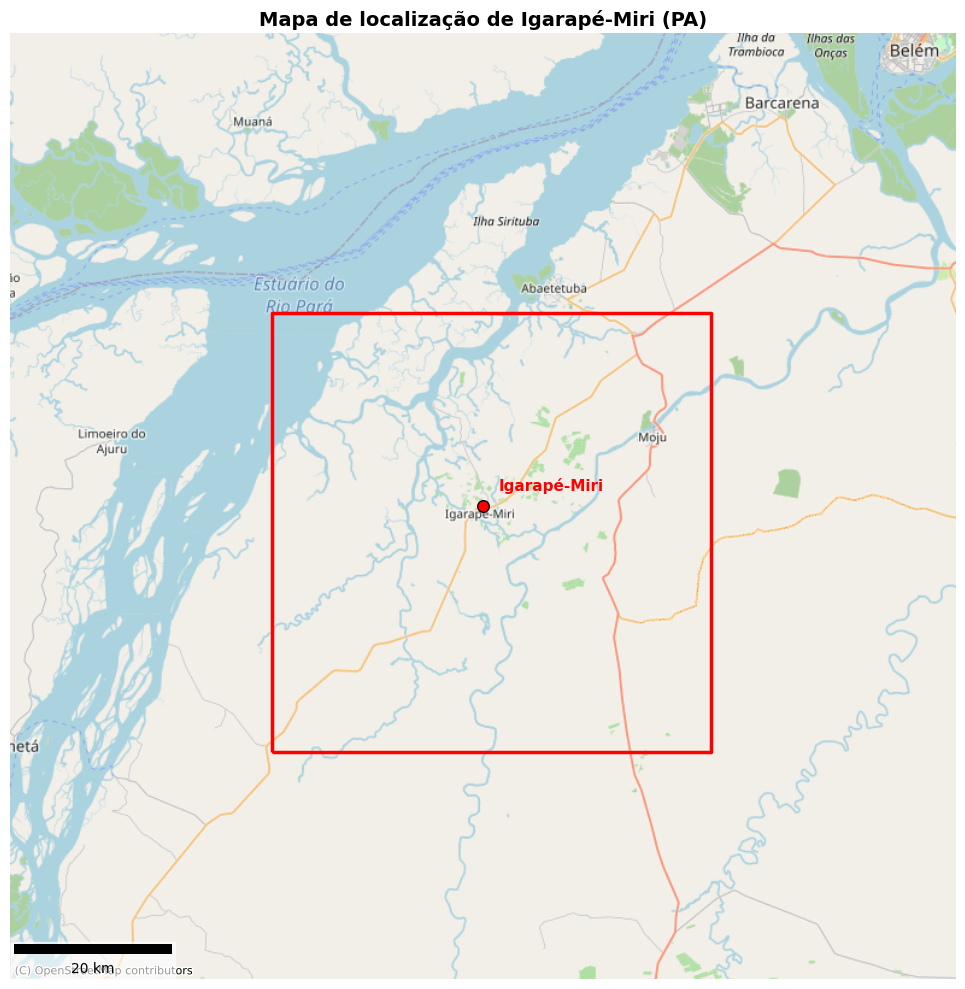

In [ ]:
# Instale as bibliotecas (caso necessário)
!pip install cartopy contextily geopandas matplotlib mercantile xyzservices matplotlib-scalebar

import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# -----------------------------
# Coordenadas de Igarapé-Miri
# -----------------------------
lon = -48.96
lat = -1.97

# Cria ponto
gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
)

# Converte para Web Mercator
gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.iloc[0]
y = gdf.geometry.y.iloc[0]

# -----------------------------
# QUADRADO (área do município)
# -----------------------------
lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

quad = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# -----------------------------
# MAPA
# -----------------------------
fig, ax = plt.subplots(figsize=(10,10))

# Ponto
ax.scatter(
    x, y,
    color='red',
    s=70,
    edgecolor='black',
    zorder=5
)

ax.text(
    x + 2000,
    y + 2000,
    "Igarapé-Miri",
    fontsize=11,
    color='red',
    weight='bold'
)

# Quadrado do município
quad.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2.5,
    zorder=4
)

# Extensão do mapa
dist = 60000
ax.set_xlim(x - dist, x + dist)
ax.set_ylim(y - dist, y + dist)

# Fundo OSM
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# -----------------------------
# ESCALA DO MAPA
# -----------------------------
scalebar = ScaleBar(
    1,               # 1 pixel = 1 unidade do CRS (Web Mercator)
    units="m",
    dimension="si-length",
    location="lower left",
    box_alpha=0.6,
    color="black"
)

ax.add_artist(scalebar)

# -----------------------------
# Finalização
# -----------------------------
ax.set_axis_off()

plt.title(
    "Mapa de localização de Igarapé-Miri (PA)",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()
plt.savefig(
    "Mapa_Localizacao_Igarape_Miri_OSM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import cdsapi

dataset = "reanalysis-era5-land-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": [
        "2m_temperature",
        "evaporation_from_vegetation_transpiration",
        "potential_evaporation",
        "total_precipitation",
        "leaf_area_index_high_vegetation",
        "leaf_area_index_low_vegetation",
        "low_vegetation_cover",
        "soil_type",
        "type_of_high_vegetation",
        "type_of_low_vegetation"
    ],
    "year": ["2025"],
    "month": ["01"],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-1.75, -49.2, -2.25, -48.7]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='1e59e4ff-9b93-4cff-8896-edd8ab12b379')
client.retrieve(dataset, request).download()

2026-07-01 14:43:53,924 INFO Request ID is a6c7feba-dd78-41a7-a43f-794bf546f8be
INFO:ecmwf.datastores.legacy_client:Request ID is a6c7feba-dd78-41a7-a43f-794bf546f8be
2026-07-01 14:43:53,984 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-01 14:44:07,545 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-01 14:44:26,622 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


f1ab0c57f1169e797af9d01aad65a65.zip:   0%|          | 0.00/101k [00:00<?, ?B/s]

'f1ab0c57f1169e797af9d01aad65a65.zip'

In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/Aula 2/cvl.area-subset.-1.75.-48.7.-2.25.-49.2.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('Vegetacaobaixa.csv')
df_converted.to_csv('Vegetacaobaixa.csv')

Vegetacaobaixa.csv


In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/Aula 2/data_stream-moda.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('dadomensal.csv')
df_converted.to_csv('dadomensal.csv')

dadomensal.csv


In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/Aula 2/slt.area-subset.-1.75.-48.7.-2.25.-49.2.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('tipodesolo.csv')
df_converted.to_csv('tipodesolo.csv')

tipodesolo.csv


In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/Aula 2/tvh.area-subset.-1.75.-48.7.-2.25.-49.2.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('tipodevegetacaoalta.csv')
df_converted.to_csv('tipodevegetacaoalta.csv')

tipodevegetacaoalta.csv


In [ ]:
ds = xr.open_dataset('/content/drive/MyDrive/Colab Notebooks/Aula 2/tvl.area-subset.-1.75.-48.7.-2.25.-49.2.nc',engine='h5netcdf')

df_converted = ds.to_dataframe()

print('tipodevegetacaobaixa.csv')
df_converted.to_csv('tipodevegetacaobaixa.csv')

tipodevegetacaobaixa.csv


In [ ]:
import pandas as pd

In [ ]:
# -----------------------------
# DADOS CSV (Vegetação)
# -----------------------------
df = pd.read_csv("tipodevegetacaoalta.csv")

# Corrigir longitude de 0–360 para -180–180
df["longitude"] = df["longitude"] - 360

# Criar GeoDataFrame
gdf_csv = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# Converter para Web Mercator
gdf_csv = gdf_csv.to_crs(epsg=3857)

In [ ]:
# Plotar vegetação
gdf_csv.plot(
    ax=ax,
    column="tvh",
    cmap="YlGn",
    markersize=120,
    alpha=0.8,
    legend=True,
    zorder=3
)

<Axes: title={'center': 'Mapa de localização de Igarapé-Miri (PA)'}>

In [ ]:
cores = {
    0: "gray",
    6.000107: "yellowgreen",
    19: "darkgreen"
}

for valor, cor in cores.items():
    subset = gdf_csv[gdf_csv["tvh"] == valor]
    subset.plot(
        ax=ax,
        color=cor,
        markersize=120,
        alpha=0.9,
        label=f"TVH = {valor}",
        zorder=3
    )

ax.legend()

/tmp/ipykernel_8878/152582483.py:9: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(


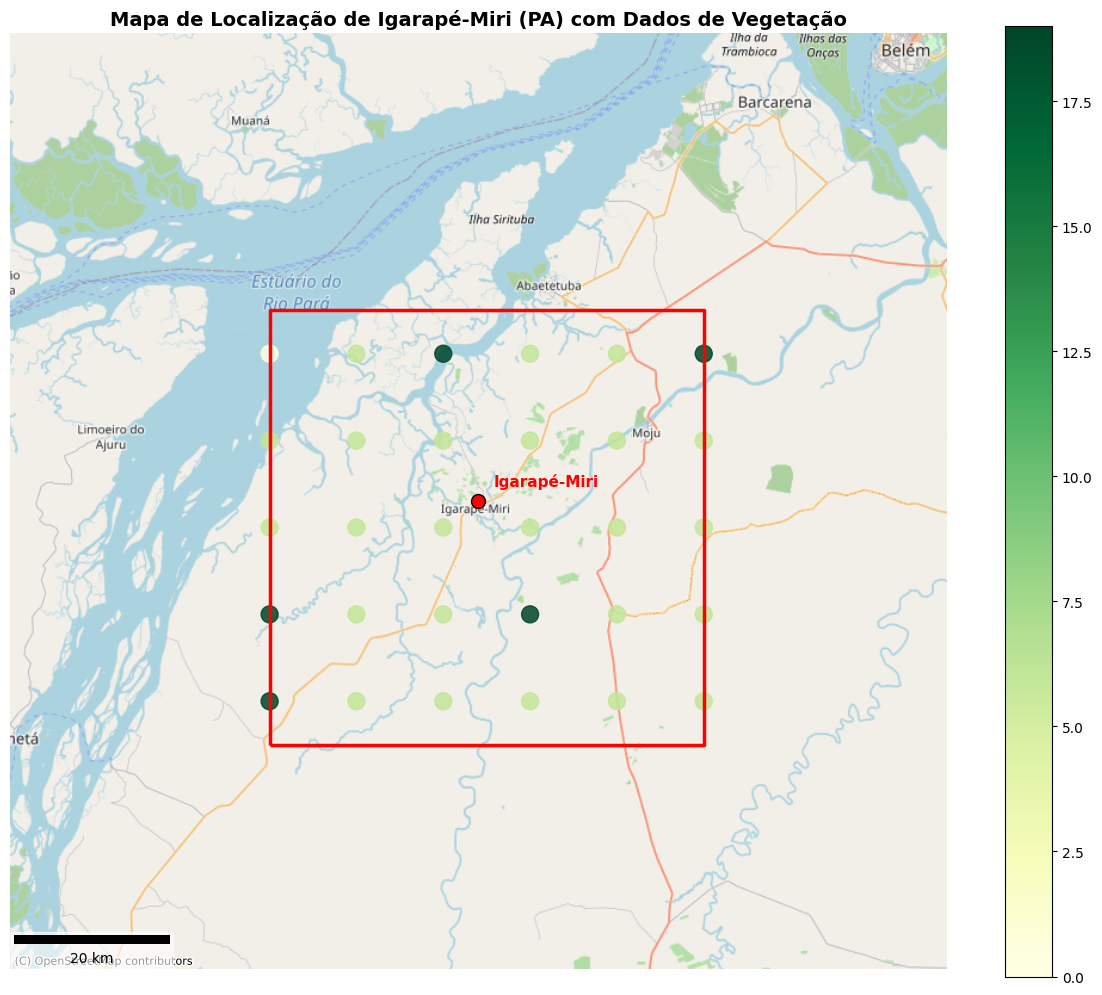

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, box
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar

# -----------------------------
# Coordenadas de Igarapé-Miri
# -----------------------------
lon = -48.96
lat = -1.97

# Cria ponto central
gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
)

# Converte para Web Mercator
gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.iloc[0]
y = gdf.geometry.y.iloc[0]

# -----------------------------
# QUADRADO (área do município)
# -----------------------------
lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

quad = gpd.GeoDataFrame(
    geometry=[box(lon_min, lat_min, lon_max, lat_max)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# -----------------------------
# DADOS CSV
# -----------------------------
df = pd.read_csv("tipodevegetacaoalta.csv")

# Corrigir longitude (0–360 → -180–180)
df["longitude"] = df["longitude"] - 360

# Criar GeoDataFrame dos pontos
gdf_csv = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# Converter para Web Mercator
gdf_csv = gdf_csv.to_crs(epsg=3857)

# -----------------------------
# MAPA
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Plotar pontos do CSV coloridos por TVH
gdf_csv.plot(
    ax=ax,
    column="tvh",
    cmap="YlGn",
    markersize=150,
    alpha=0.85,
    legend=True,
    zorder=3
)

# Ponto central
ax.scatter(
    x, y,
    color='red',
    s=100,
    edgecolor='black',
    zorder=5
)

# Texto do município
ax.text(
    x + 2000,
    y + 2000,
    "Igarapé-Miri",
    fontsize=11,
    color='red',
    weight='bold'
)

# Contorno do município
quad.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2.5,
    zorder=4
)

# Extensão do mapa
dist = 60000
ax.set_xlim(x - dist, x + dist)
ax.set_ylim(y - dist, y + dist)

# Fundo OSM
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# -----------------------------
# ESCALA
# -----------------------------
scalebar = ScaleBar(
    1,
    units="m",
    dimension="si-length",
    location="lower left",
    box_alpha=0.6,
    color="black"
)

ax.add_artist(scalebar)

# -----------------------------
# FINALIZAÇÃO
# -----------------------------
ax.set_axis_off()

plt.title(
    "Mapa de Localização de Igarapé-Miri (PA) com Dados de Vegetação",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.savefig(
    "Mapa_Igarape_Miri_Vegetacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

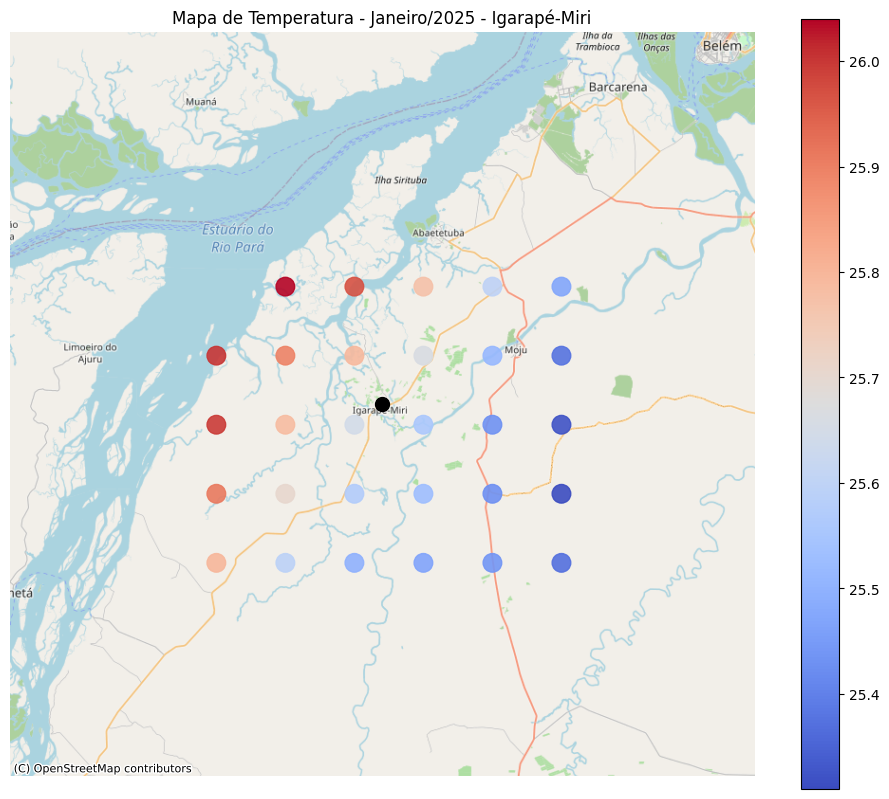

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, box
import contextily as ctx

# -----------------------------
# Ler CSV
# -----------------------------
df = pd.read_csv("dadomensal.csv")

# Corrigir longitude
df["longitude"] = df["longitude"] - 360

# Converter temperatura Kelvin -> Celsius
df["t2m"] = df["t2m"] - 273.15

# Criar GeoDataFrame
gdf_csv = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

gdf_csv = gdf_csv.to_crs(epsg=3857)

# -----------------------------
# Coordenadas Igarapé-Miri
# -----------------------------
lon = -48.96
lat = -1.97

gdf = gpd.GeoDataFrame(
    geometry=[Point(lon, lat)],
    crs="EPSG:4326"
).to_crs(epsg=3857)

x = gdf.geometry.x.iloc[0]
y = gdf.geometry.y.iloc[0]

# -----------------------------
# Mapa
# -----------------------------
fig, ax = plt.subplots(figsize=(12,10))

# Plotar temperatura
gdf_csv.plot(
    ax=ax,
    column="t2m",
    cmap="coolwarm",
    markersize=180,
    alpha=0.9,
    legend=True
)

# Ponto central
ax.scatter(x, y, color='black', s=100)

dist = 60000
ax.set_xlim(x-dist, x+dist)
ax.set_ylim(y-dist, y+dist)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Mapa de Temperatura - Janeiro/2025 - Igarapé-Miri")
plt.show()

In [ ]:
!pip install cartopy scipy geopandas

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


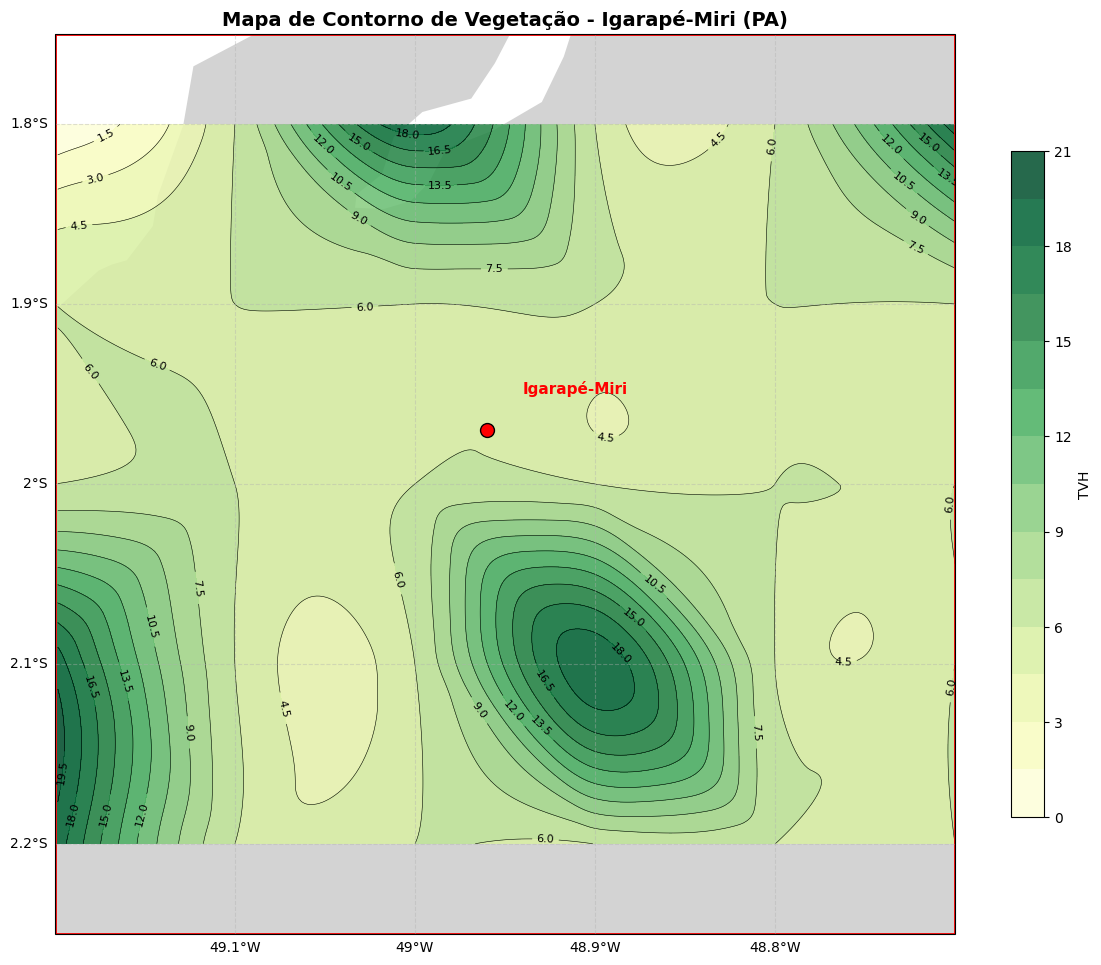

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import geopandas as gpd

# -----------------------------
# Coordenadas de Igarapé-Miri
# -----------------------------
lon = -48.96
lat = -1.97

lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

# -----------------------------
# Ler CSV
# -----------------------------
df = pd.read_csv("tipodevegetacaoalta.csv")

# Corrigir longitude
df["longitude"] = df["longitude"] - 360

# -----------------------------
# Preparar dados
# -----------------------------
x = df["longitude"].values
y = df["latitude"].values
z = df["tvh"].values

# Grade regular para interpolação
grid_x, grid_y = np.meshgrid(
    np.linspace(lon_min, lon_max, 300),
    np.linspace(lat_min, lat_max, 300)
)

# Interpolação
grid_z = griddata(
    (x, y),
    z,
    (grid_x, grid_y),
    method="cubic"
)

# -----------------------------
# Plot com Cartopy
# -----------------------------
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extensão do mapa
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Base cartográfica
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.RIVERS, alpha=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Contorno preenchido
contourf = ax.contourf(
    grid_x,
    grid_y,
    grid_z,
    levels=15,
    cmap="YlGn",
    transform=ccrs.PlateCarree(),
    alpha=0.85
)

# Linhas de contorno
contour = ax.contour(
    grid_x,
    grid_y,
    grid_z,
    levels=15,
    colors='black',
    linewidths=0.4,
    transform=ccrs.PlateCarree()
)

# Labels nas linhas
ax.clabel(contour, inline=True, fontsize=8)

# Limite do município (quadrado)
quad = box(lon_min, lat_min, lon_max, lat_max)
gpd.GeoSeries([quad]).boundary.plot(
    ax=ax,
    edgecolor='red',
    linewidth=2,
    transform=ccrs.PlateCarree()
)

# Ponto central
ax.scatter(
    lon,
    lat,
    color='red',
    s=100,
    edgecolor='black',
    transform=ccrs.PlateCarree(),
    zorder=5
)

# Nome
ax.text(
    lon + 0.02,
    lat + 0.02,
    "Igarapé-Miri",
    color='red',
    fontsize=11,
    weight='bold',
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(contourf, ax=ax, shrink=0.7)
cbar.set_label("TVH")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

# Título
plt.title(
    "Mapa de Contorno de Vegetação - Igarapé-Miri (PA)",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()
plt.show()

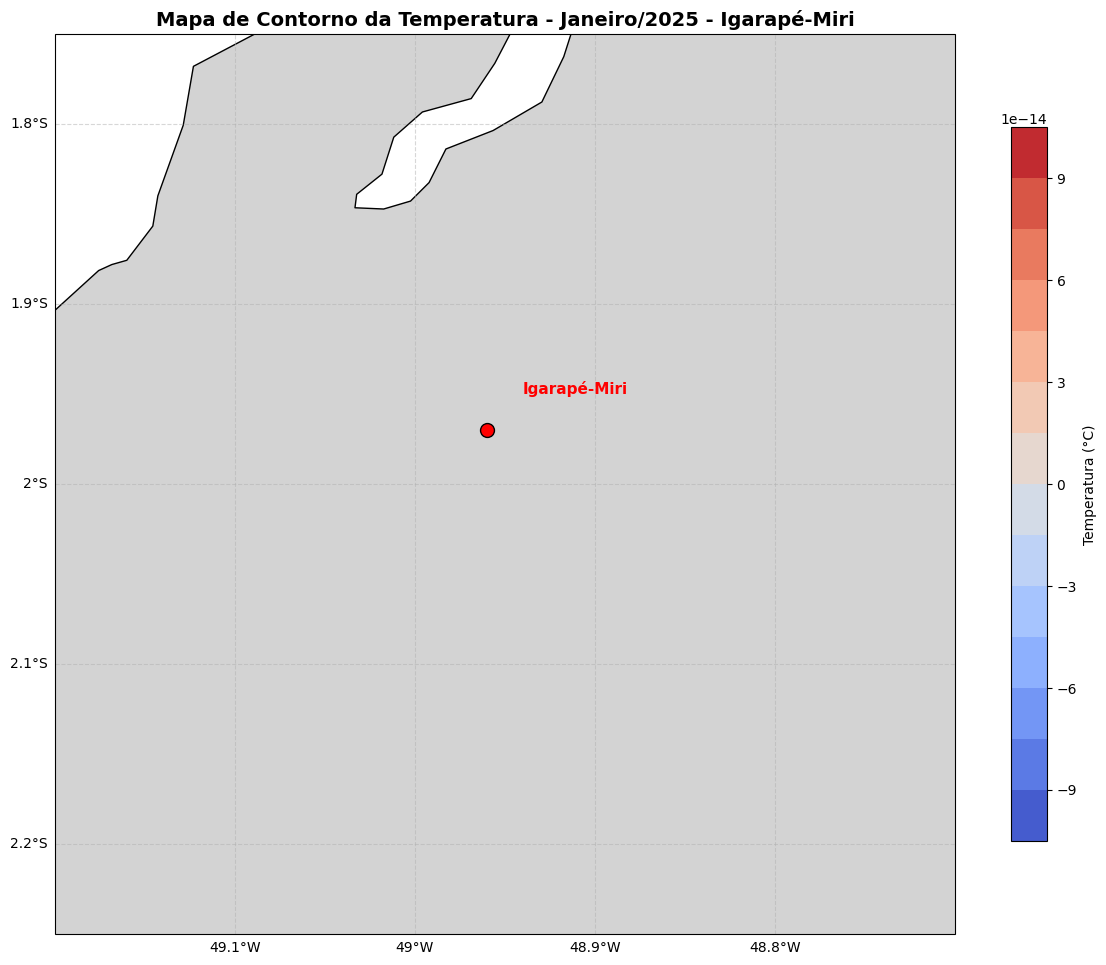

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# Limites de Igarapé-Miri
# -----------------------------
lon_min = -49.20
lon_max = -48.70
lat_min = -2.25
lat_max = -1.75

# Centro
lon = -48.96
lat = -1.97

# -----------------------------
# Ler CSV
# -----------------------------
df = pd.read_csv("dadomensal.csv")

# Corrigir longitude (0–360 -> -180–180)
df["longitude"] = df["longitude"] - 360

# Temperatura Kelvin -> Celsius
df["t2m"] = df["t2m"] - 273.15

# -----------------------------
# Dados para interpolação
# -----------------------------
x = df["longitude"].values
y = df["latitude"].values
z = df["t2m"].values

# Criar grade regular
grid_x, grid_y = np.meshgrid(
    np.linspace(lon_min, lon_max, 300),
    np.linspace(lat_min, lat_max, 300)
)

# Interpolação espacial
grid_z = griddata(
    (x, y),
    z,
    (grid_x, grid_y),
    method="cubic"
)

# -----------------------------
# Criar mapa
# -----------------------------
fig = plt.figure(figsize=(12,10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extensão do mapa
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Base cartográfica
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.RIVERS, alpha=0.4)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# -----------------------------
# Contorno preenchido
# -----------------------------
contourf = ax.contourf(
    grid_x,
    grid_y,
    grid_z,
    levels=15,
    cmap="coolwarm",
    transform=ccrs.PlateCarree()
)

# -----------------------------
# Linhas de contorno
# -----------------------------
contour = ax.contour(
    grid_x,
    grid_y,
    grid_z,
    levels=15,
    colors='black',
    linewidths=0.6,
    transform=ccrs.PlateCarree()
)

# Labels
ax.clabel(contour, inline=True, fontsize=8)

# -----------------------------
# Ponto central
# -----------------------------
ax.scatter(
    lon,
    lat,
    color='red',
    s=100,
    edgecolor='black',
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.text(
    lon + 0.02,
    lat + 0.02,
    "Igarapé-Miri",
    fontsize=11,
    color='red',
    weight='bold',
    transform=ccrs.PlateCarree()
)

# -----------------------------
# Barra de cores
# -----------------------------
cbar = plt.colorbar(contourf, ax=ax, shrink=0.75)
cbar.set_label("Temperatura (°C)")

# -----------------------------
# Gridlines
# -----------------------------
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# -----------------------------
# Título
# -----------------------------
plt.title(
    "Mapa de Contorno da Temperatura - Janeiro/2025 - Igarapé-Miri",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()
plt.show()

In [ ]:
!pip install geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.4 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.1.1
    Uninstalling lxml-6.1.1:
      Successfully uninstalled lxml-6.1.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.3
    Uninstalling geopandas-1.1.3:
      Successfully uninstalled geopandas-1.1.3


In [ ]:
!pip install geobr

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
import geobr

# -------------------------
# Municípios
# -------------------------

municipios = geobr.read_municipality(year=2020)

# -------------------------
# SIDRA
# -------------------------

url = (
    "https://apisidra.ibge.gov.br/values/"
    "t/5457/n6/all/v/214/p/last%201/c782/45982"
)

df = pd.read_json(url)

# Remove a primeira linha (cabeçalho da API)
df = df.iloc[1:].copy()

# Renomeia colunas
df = df.rename(columns={
    "D1C": "cod_municipio",
    "D1N": "municipio",
    "V": "producao_t"
})

# Converte tipos
df["cod_municipio"] = df["cod_municipio"].astype(str)
df["producao_t"] = pd.to_numeric(df["producao_t"], errors="coerce")

# -------------------------
# Merge
# -------------------------

municipios['code_muni'] = municipios['code_muni'].astype(int).astype(str)

# Note: pam was not defined in the current context, it should be 'df' here.
# Re-evaluating based on the latest notebook state:
# The previous code had a 'pam' DataFrame which was the result of a pivot_table operation.
# However, the current code in RRL2DJIRr8zx now uses 'df' directly from the API call after some cleaning.
# Therefore, the merge should be with 'df' and not 'pam'.
# I will use 'df' for the merge, consistent with the current cell's logic.
# I will also add a comment to clarify this potential confusion if 'pam' was expected.

gdf = municipios.merge(
    df[["cod_municipio", "producao_t"]],
    left_on="code_muni",
    right_on="cod_municipio",
    how="left"
)

gdf["producao_t"] = gdf["producao_t"].fillna(0)

# Re-project to a suitable projected CRS (e.g., a common UTM zone for Brazil or a global projection) for accurate centroid calculation
# The EPSG:3857 (Web Mercator) is a common projected CRS, but for high-precision area calculations, a more localized UTM zone might be better.
# For a country-wide context like Brazil, EPSG:3857 is often a reasonable compromise for visualization and approximate centroids.
# If higher precision is needed for area/distance across the whole country, one might consider using an Albers Equal Area Conic projection, or reprojecting to local UTM zones per state.
# For now, let's use a widely supported projected CRS like Web Mercator (EPSG:3857).
gdf_projected = gdf.to_crs(epsg=3857)

# Add a column for the centroids of the polygons using the projected GeoDataFrame
gdf['centroid'] = gdf_projected.geometry.centroid

print(gdf)

     code_muni              name_muni  code_state abbrev_state  \
0      1100015  Alta Floresta D'oeste        11.0           RO   
1      1100023              Ariquemes        11.0           RO   
2      1100031                 Cabixi        11.0           RO   
3      1100049                 Cacoal        11.0           RO   
4      1100056             Cerejeiras        11.0           RO   
...        ...                    ...         ...          ...   
5565   5222005             Vianópolis        52.0           GO   
5566   5222054         Vicentinópolis        52.0           GO   
5567   5222203               Vila Boa        52.0           GO   
5568   5222302          Vila Propício        52.0           GO   
5569   5300108               Brasília        53.0           DF   

            name_state  code_region   name_region  \
0             Rondônia          1.0         Norte   
1             Rondônia          1.0         Norte   
2             Rondônia          1.0         Nort

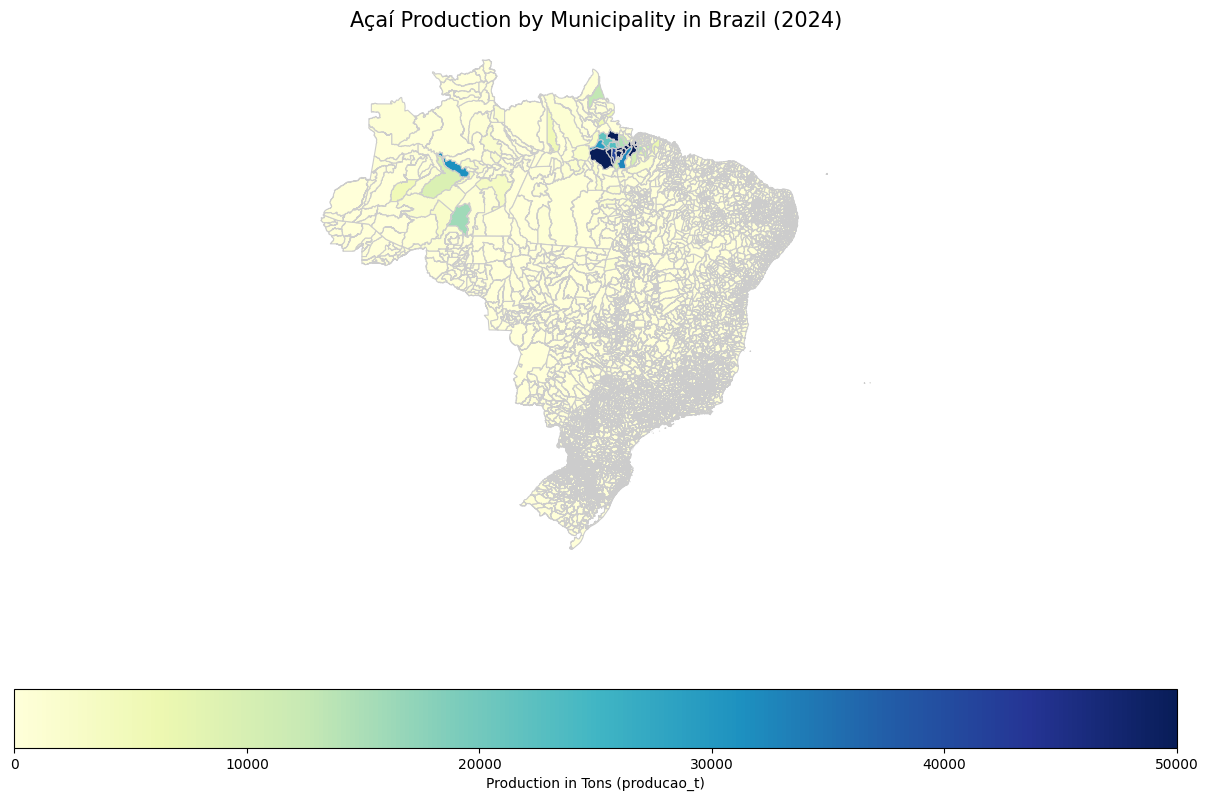

In [ ]:
import matplotlib.pyplot as plt

# Create the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf.plot(
    column='producao_t',
    cmap='YlGnBu',  # Choose a color map (Yellow-Green-Blue is good for sequential data)
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Production in Tons (producao_t)", 'orientation': "horizontal"},
    vmax=50000 # Set the maximum value of the color scale
)

ax.set_title('Açaí Production by Municipality in Brazil (2024)', fontsize=15)
ax.set_axis_off() # Remove axes for a cleaner map
plt.show()

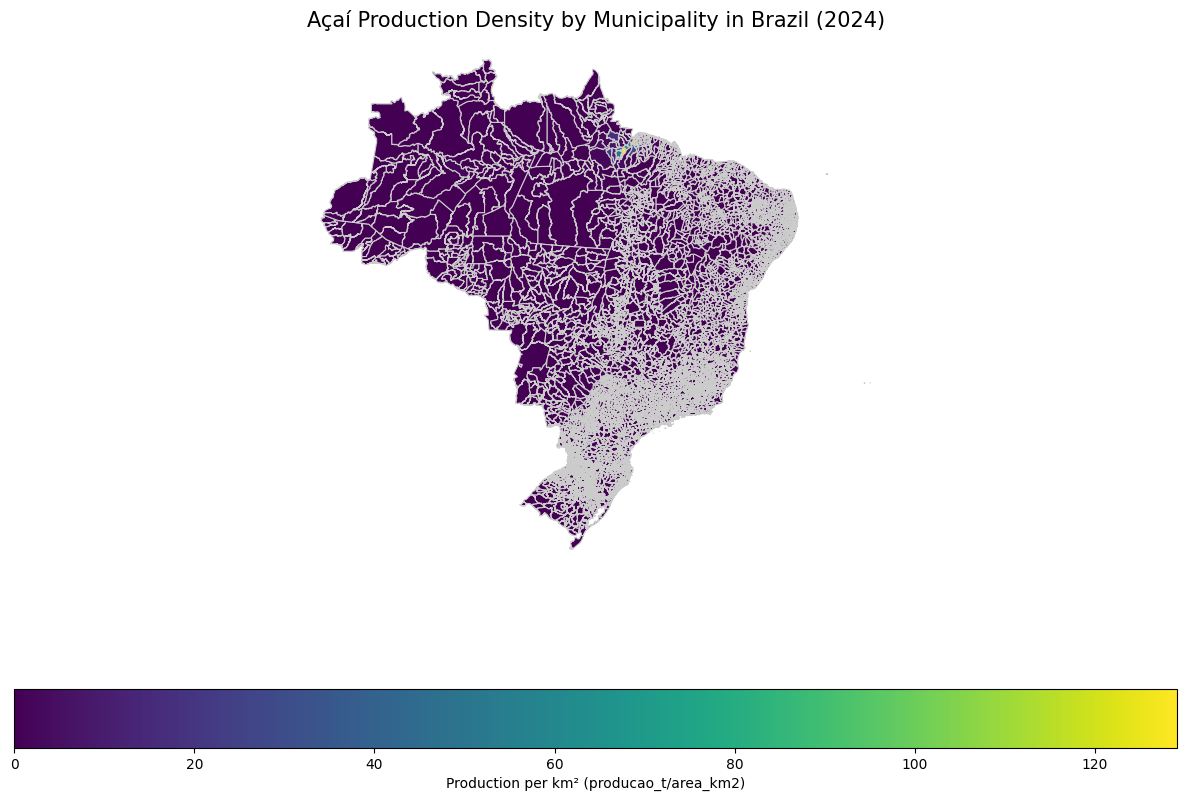

In [ ]:
import numpy as np

# Ensure 'area_km2' is available in the gdf.
# First, re-project gdf to a projected CRS for accurate area calculation.
# EPSG:3857 (Web Mercator) is a common choice for global projections and general purpose.
gdf_projected_for_area = gdf.to_crs(epsg=3857)

# Calculate the area in square meters and convert to square kilometers
# geopandas .area returns area in the units of the CRS. For EPSG:3857 (meters), it's m^2.
gdf['area_km2'] = gdf_projected_for_area.geometry.area * 1e-6

# Calculate production per square kilometer
# Handle potential division by zero by replacing infinities with NaN and then filling with 0 if desired.
gdf['producao_per_km2'] = gdf['producao_t'] / gdf['area_km2']
gdf['producao_per_km2'] = gdf['producao_per_km2'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Create the choropleth map for production per km2
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

gdf.plot(
    column='producao_per_km2',
    cmap='viridis', # 'viridis' is a good perceptually uniform colormap
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Production per km² (producao_t/area_km2)", 'orientation': "horizontal"}
)

ax.set_title('Açaí Production Density by Municipality in Brazil (2024)', fontsize=15)
ax.set_axis_off()
plt.show()